In [1]:
import pandas as pd
import matplotlib.pyplot as plt

INPUT_CSV = "/home/thsu/FRB_population/CHIME_spectra/combined_alpha_sep.csv"

df = pd.read_csv(INPUT_CSV)


In [2]:
clean = df.dropna(subset=["sep_deg", "alpha_base", "alpha_err_base"])


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, RealData

def linear(B, x):
    return B[0] * x + B[1]

x = clean["alpha_base"].values
y = clean["alpha_cat1"].values
xerr = clean["alpha_err_base"].values
yerr = clean["alpha_err_cat1"].values
n_total = len(x)

# --- Manually mask out points from the fit ---
drop_idx = []  # <-- put row indices to exclude here, e.g. [3, 47, 112]
mask = np.ones(len(x), dtype=bool)
mask[drop_idx] = False

x_m, y_m = x[mask], y[mask]
xerr_m, yerr_m = xerr[mask], yerr[mask]

# --- Count points below y = x ---
below_mask = y < x
n_below = below_mask.sum()
frac_below = n_below / n_total
print(f"points below y=x: {n_below} / {n_total} ({frac_below:.1%})")

# --- Point-estimate ODR fit on masked data ---
odr_model = Model(linear)
odr_data = RealData(x_m, y_m, sx=xerr_m, sy=yerr_m)
odr = ODR(odr_data, odr_model, beta0=[1.0, 0.0])
out = odr.run()
a0, b0 = out.beta
a0_err, b0_err = out.sd_beta
print(f"masked ODR fit: y = ({a0:.3f} \u00b1 {a0_err:.3f}) x + ({b0:.3f} \u00b1 {b0_err:.3f})")
print(f"residual variance (~reduced chi^2 analog): {out.res_var:.2f}")


points below y=x: 98 / 130 (75.4%)
masked ODR fit: y = (1.072 ± 0.111) x + (-0.674 ± 0.088)
residual variance (~reduced chi^2 analog): 51.88


In [4]:
# --- Helper functions ---
def perp_residuals(x, y, xerr, yerr, beta):
    """Signed perpendicular distance from the fit line, in units of sigma."""
    a, b = beta
    d = (y - a * x - b) / np.sqrt(1 + a**2)
    sigma_perp = np.sqrt(yerr**2 + (a * xerr)**2) / np.sqrt(1 + a**2)
    return d / sigma_perp

def refit_odr(x, y, xerr, yerr, beta0):
    data = RealData(x, y, sx=xerr, sy=yerr)
    odr = ODR(data, odr_model, beta0=list(beta0))
    return odr.run()

def plot_fit_stage(x_used, y_used, xerr_used, yerr_used, beta,
                    x_excl, y_excl, xerr_excl, yerr_excl,
                    title, n_total, n_below, frac_below):
    """Plot data (used vs excluded) with the fit line and y=x reference."""
    a, b = beta
    fig, ax = plt.subplots(figsize=(7, 6), dpi=150)

    all_x = np.concatenate([x_used, x_excl]) if len(x_excl) else x_used
    all_y = np.concatenate([y_used, y_excl]) if len(y_excl) else y_used
    lims = [min(all_x.min(), all_y.min()), max(all_x.max(), all_y.max())]
    x_fit = np.linspace(lims[0], lims[1], 200)

    ax.plot(x_fit, a * x_fit + b, color="black", linewidth=2,
            label=fr"ODR fit: $y=({a:.2f})x+({b:.2f})$", zorder=3)
    ax.plot(lims, lims, "k--", linewidth=1.5, label=r"$y=x$", zorder=2)

    ax.errorbar(x_used, y_used, xerr=xerr_used, yerr=yerr_used,
                fmt="o", markersize=5, capsize=3, elinewidth=1,
                color="tab:blue", ecolor="tab:gray", label="data (used)", zorder=2)

    if len(x_excl):
        ax.errorbar(x_excl, y_excl, xerr=xerr_excl, yerr=yerr_excl,
                    fmt="x", markersize=6, capsize=3, elinewidth=1,
                    color="tab:red", ecolor="tab:red", alpha=0.7,
                    label="excluded", zorder=2)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(r"$\alpha_{\mathrm{base}}$")
    ax.set_ylabel(r"$\alpha_{\mathrm{cat1}}$")
    ax.set_title(title)
    ax.legend(loc="upper left")

    mid_x = 0.5 * (lims[0] + lims[1])
    ax.text(
        mid_x + 3, mid_x - 4,
        f"below $y=x$: {n_below}/{n_total} ({frac_below:.1%})",
        fontsize=9, color="black", ha="center", va="top",
    )
    plt.show()


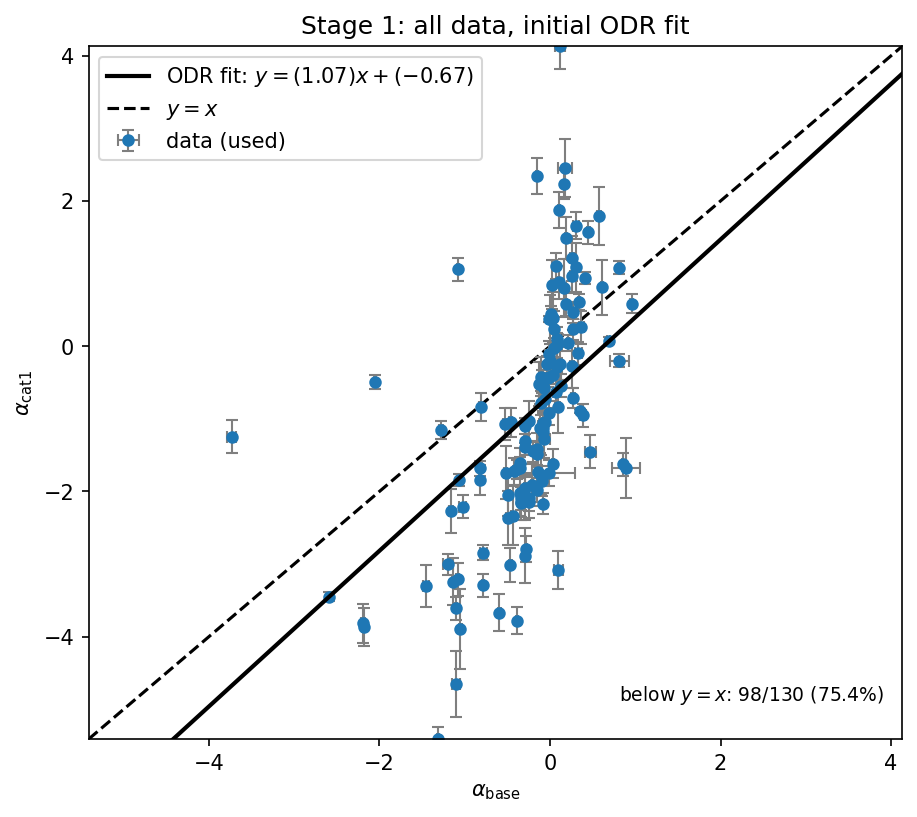

In [5]:
# --- Stage 1 plot: all data (manually masked only), initial fit ---
plot_fit_stage(
    x_m, y_m, xerr_m, yerr_m, out.beta,
    x[~mask], y[~mask], xerr[~mask], yerr[~mask],
    title="Stage 1: all data, initial ODR fit",
    n_total=n_total, n_below=n_below, frac_below=frac_below,
)


In [6]:
# --- Stage 2: remove >10-sigma outliers, refit ---
resid0 = perp_residuals(x_m, y_m, xerr_m, yerr_m, out.beta)
outliers_10sigma = np.abs(resid0) > 10
keep_10 = ~outliers_10sigma

print(f"{outliers_10sigma.sum()} points removed as >10\u03c3 outliers "
      f"(out of {len(x_m)})")

x_10, y_10 = x_m[keep_10], y_m[keep_10]
xerr_10, yerr_10 = xerr_m[keep_10], yerr_m[keep_10]

out_10 = refit_odr(x_10, y_10, xerr_10, yerr_10, beta0=out.beta)
a10, b10 = out_10.beta
a10_err, b10_err = out_10.sd_beta
print(f"refit after 10\u03c3 clip: y = ({a10:.3f} \u00b1 {a10_err:.3f}) x "
      f"+ ({b10:.3f} \u00b1 {b10_err:.3f})")
print(f"residual variance: {out_10.res_var:.2f}")


18 points removed as >10σ outliers (out of 130)
refit after 10σ clip: y = (1.263 ± 0.082) x + (-0.654 ± 0.069)
residual variance: 19.22


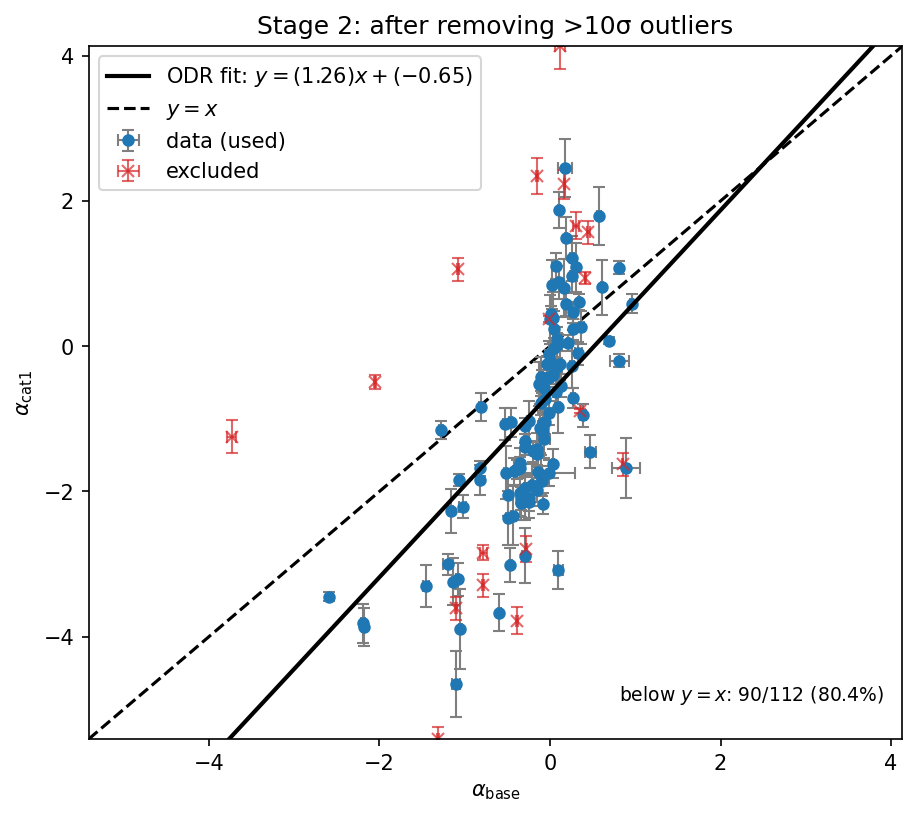

In [7]:
# --- Stage 2 plot: after 10-sigma clip ---
# points excluded at this stage = manually dropped + newly clipped 10-sigma outliers
x_excl_10 = np.concatenate([x[~mask], x_m[outliers_10sigma]])
y_excl_10 = np.concatenate([y[~mask], y_m[outliers_10sigma]])
xerr_excl_10 = np.concatenate([xerr[~mask], xerr_m[outliers_10sigma]])
yerr_excl_10 = np.concatenate([yerr[~mask], yerr_m[outliers_10sigma]])

n_below_10 = (y_10 < x_10).sum()
n_total_10 = len(x_10)
frac_below_10 = n_below_10 / n_total_10

plot_fit_stage(
    x_10, y_10, xerr_10, yerr_10, out_10.beta,
    x_excl_10, y_excl_10, xerr_excl_10, yerr_excl_10,
    title="Stage 2: after removing >10\u03c3 outliers",
    n_total=n_total_10, n_below=n_below_10, frac_below=frac_below_10,
)


In [8]:
# --- Stage 3: remove >5-sigma outliers (on 10-sigma-clipped fit), refit ---
resid_10 = perp_residuals(x_10, y_10, xerr_10, yerr_10, out_10.beta)
outliers_5sigma = np.abs(resid_10) > 5
keep_5 = ~outliers_5sigma

print(f"{outliers_5sigma.sum()} additional points removed as >5\u03c3 outliers "
      f"(out of {len(x_10)})")

x_5, y_5 = x_10[keep_5], y_10[keep_5]
xerr_5, yerr_5 = xerr_10[keep_5], yerr_10[keep_5]

out_5 = refit_odr(x_5, y_5, xerr_5, yerr_5, beta0=out_10.beta)
a5, b5 = out_5.beta
a5_err, b5_err = out_5.sd_beta
print(f"refit after 5\u03c3 clip: y = ({a5:.3f} \u00b1 {a5_err:.3f}) x "
      f"+ ({b5:.3f} \u00b1 {b5_err:.3f})")
print(f"residual variance: {out_5.res_var:.2f}")


31 additional points removed as >5σ outliers (out of 112)
refit after 5σ clip: y = (1.382 ± 0.100) x + (-0.681 ± 0.052)
residual variance: 7.64


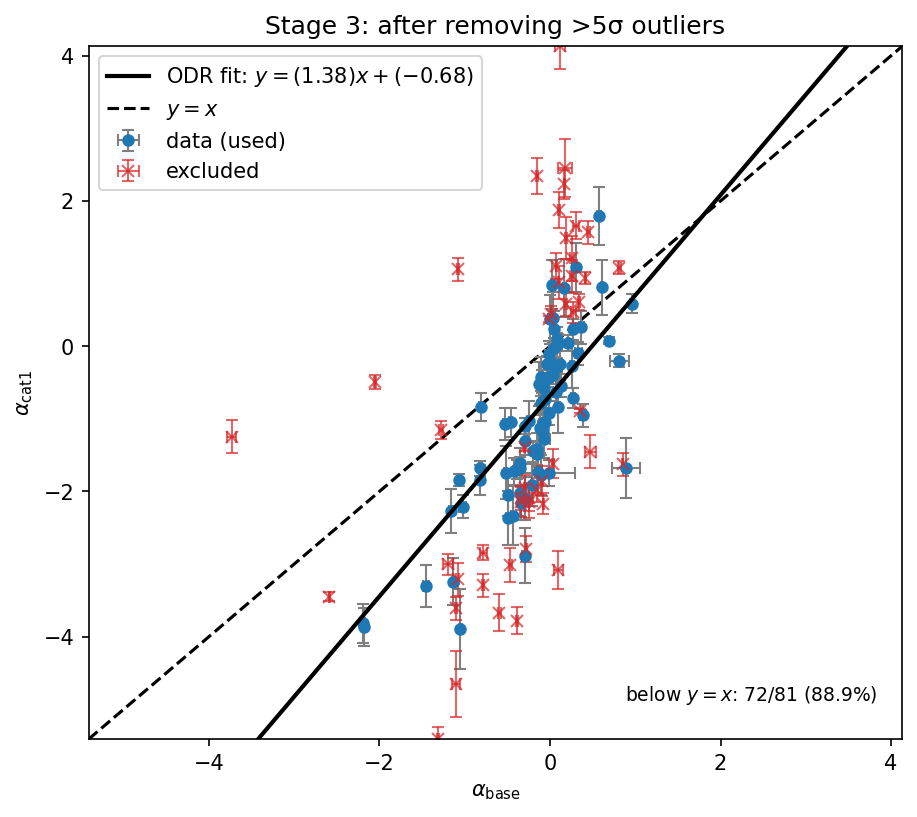

In [9]:
# --- Stage 3 plot: after 5-sigma clip ---
# excluded at this stage = everything excluded so far + newly clipped 5-sigma outliers
x_excl_5 = np.concatenate([x_excl_10, x_10[outliers_5sigma]])
y_excl_5 = np.concatenate([y_excl_10, y_10[outliers_5sigma]])
xerr_excl_5 = np.concatenate([xerr_excl_10, xerr_10[outliers_5sigma]])
yerr_excl_5 = np.concatenate([yerr_excl_10, yerr_10[outliers_5sigma]])

n_below_5 = (y_5 < x_5).sum()
n_total_5 = len(x_5)
frac_below_5 = n_below_5 / n_total_5

plot_fit_stage(
    x_5, y_5, xerr_5, yerr_5, out_5.beta,
    x_excl_5, y_excl_5, xerr_excl_5, yerr_excl_5,
    title="Stage 3: after removing >5\u03c3 outliers",
    n_total=n_total_5, n_below=n_below_5, frac_below=frac_below_5,
)


In [10]:
# --- Reduced chi-square at each stage ---
# scipy ODR's `res_var` is already the reduced chi-square (chi^2 / dof) for the
# orthogonal-distance fit given the supplied x/y errors. We recompute it
# explicitly here (using the same perpendicular-residual definition used for
# sigma-clipping) so the numbers are transparent, then compare to `res_var`.
def reduced_chi2_odr(x, y, xerr, yerr, beta):
    resid_sigma = perp_residuals(x, y, xerr, yerr, beta)  # residual / sigma_perp
    chi2 = np.sum(resid_sigma**2)
    dof = len(x) - len(beta)  # n_points - n_fit_params (slope, intercept)
    return chi2, dof, chi2 / dof

stage_results = [
    ("Stage 1: all data (manual mask only)", x_m, y_m, xerr_m, yerr_m, out),
    ("Stage 2: after >10\u03c3 clip",            x_10, y_10, xerr_10, yerr_10, out_10),
    ("Stage 3: after >5\u03c3 clip",             x_5, y_5, xerr_5, yerr_5, out_5),
]

col_stage, col_n, col_chi2, col_dof, col_rchi2, col_resvar = "stage", "N", "chi2", "dof", "chi2/dof", "res_var"
print(f"{col_stage:38s} {col_n:>6s} {col_chi2:>10s} {col_dof:>6s} {col_rchi2:>10s} {col_resvar:>10s}")
for label, xs, ys, xerrs, yerrs, fit in stage_results:
    chi2, dof, red_chi2 = reduced_chi2_odr(xs, ys, xerrs, yerrs, fit.beta)
    print(f"{label:38s} {len(xs):6d} {chi2:10.2f} {dof:6d} {red_chi2:10.3f} {fit.res_var:10.3f}")


stage                                       N       chi2    dof   chi2/dof    res_var
Stage 1: all data (manual mask only)      130    6641.05    128     51.883     51.883
Stage 2: after >10σ clip                  112    2114.29    110     19.221     19.221
Stage 3: after >5σ clip                    81     603.61     79      7.641      7.641


In [11]:
# --- Point the downstream Monte Carlo / plotting code at the fully cleaned sample ---
x_m, y_m = x_5, y_5
xerr_m, yerr_m = xerr_5, yerr_5
odr_data = RealData(x_m, y_m, sx=xerr_m, sy=yerr_m)
out = out_5  # so later cells that reference `out` use the cleaned fit


In [12]:
# --- Monte Carlo resampling on cleaned+masked data, refitting with ODR each draw ---
n_iter = 5000
rng = np.random.default_rng()
slopes = np.full(n_iter, np.nan)
intercepts = np.full(n_iter, np.nan)

for i in range(n_iter):
    x_sample = rng.normal(x_m, xerr_m)
    y_sample = rng.normal(y_m, yerr_m)
    try:
        odr_data_i = RealData(x_sample, y_sample, sx=xerr_m, sy=yerr_m)
        odr_i = ODR(odr_data_i, odr_model, beta0=[1.0, 0.0])
        out_i = odr_i.run()
        if np.all(np.isfinite(out_i.beta)):
            slopes[i], intercepts[i] = out_i.beta
    except Exception:
        continue

good = np.isfinite(slopes)
slopes, intercepts = slopes[good], intercepts[good]
print(f"{good.sum()}/{n_iter} MC draws converged")

a_med, b_med = np.median(slopes), np.median(intercepts)
a_lo, a_hi = np.percentile(slopes, [16, 84])
b_lo, b_hi = np.percentile(intercepts, [16, 84])
print(f"slope = {a_med:.3f} (+{a_hi-a_med:.3f} / -{a_med-a_lo:.3f})")
print(f"intercept = {b_med:.3f} (+{b_hi-b_med:.3f} / -{b_med-b_lo:.3f})")


5000/5000 MC draws converged
slope = 1.383 (+0.037 / -0.038)
intercept = -0.681 (+0.019 / -0.018)


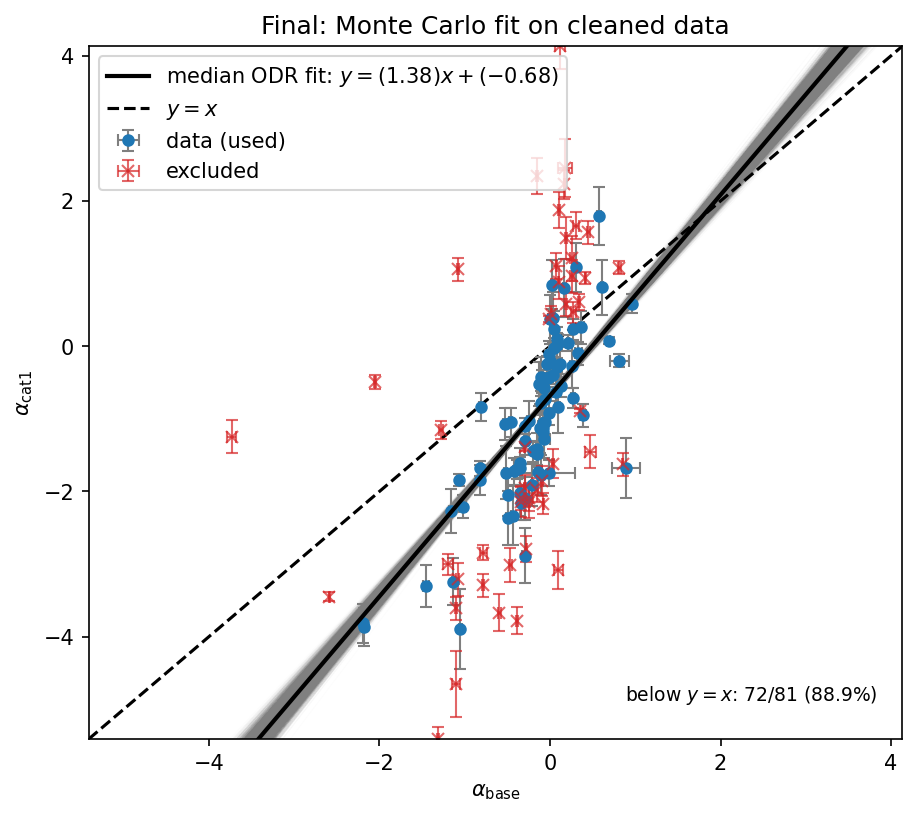

In [13]:
# --- Final plot with MC fit-line spread ---
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
x_fit = np.linspace(lims[0], lims[1], 200)

for s, ic in zip(slopes, intercepts):
    ax.plot(x_fit, s * x_fit + ic, color="gray", alpha=0.02, linewidth=0.5, zorder=1)

y_median = a_med * x_fit + b_med
ax.plot(x_fit, y_median, color="black", linewidth=2,
        label=fr"median ODR fit: $y=({a_med:.2f})x+({b_med:.2f})$", zorder=3)
ax.plot(lims, lims, "k--", linewidth=1.5, label=r"$y=x$", zorder=2)

ax.errorbar(x_m, y_m, xerr=xerr_m, yerr=yerr_m,
            fmt="o", markersize=5, capsize=3, elinewidth=1,
            color="tab:blue", ecolor="tab:gray", label="data (used)", zorder=2)

if len(x_excl_5):
    ax.errorbar(x_excl_5, y_excl_5, xerr=xerr_excl_5, yerr=yerr_excl_5,
                fmt="x", markersize=6, capsize=3, elinewidth=1,
                color="tab:red", ecolor="tab:red", alpha=0.7, label="excluded", zorder=2)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r"$\alpha_{\mathrm{base}}$")
ax.set_ylabel(r"$\alpha_{\mathrm{cat1}}$")
ax.set_title("Final: Monte Carlo fit on cleaned data")
ax.legend(loc="upper left")

mid_x = 0.5 * (lims[0] + lims[1])
ax.text(
    mid_x + 3, mid_x - 4,
    f"below $y=x$: {n_below_5}/{n_total_5} ({frac_below_5:.1%})",
    fontsize=9, color="black", ha="center", va="top",
)
plt.show()


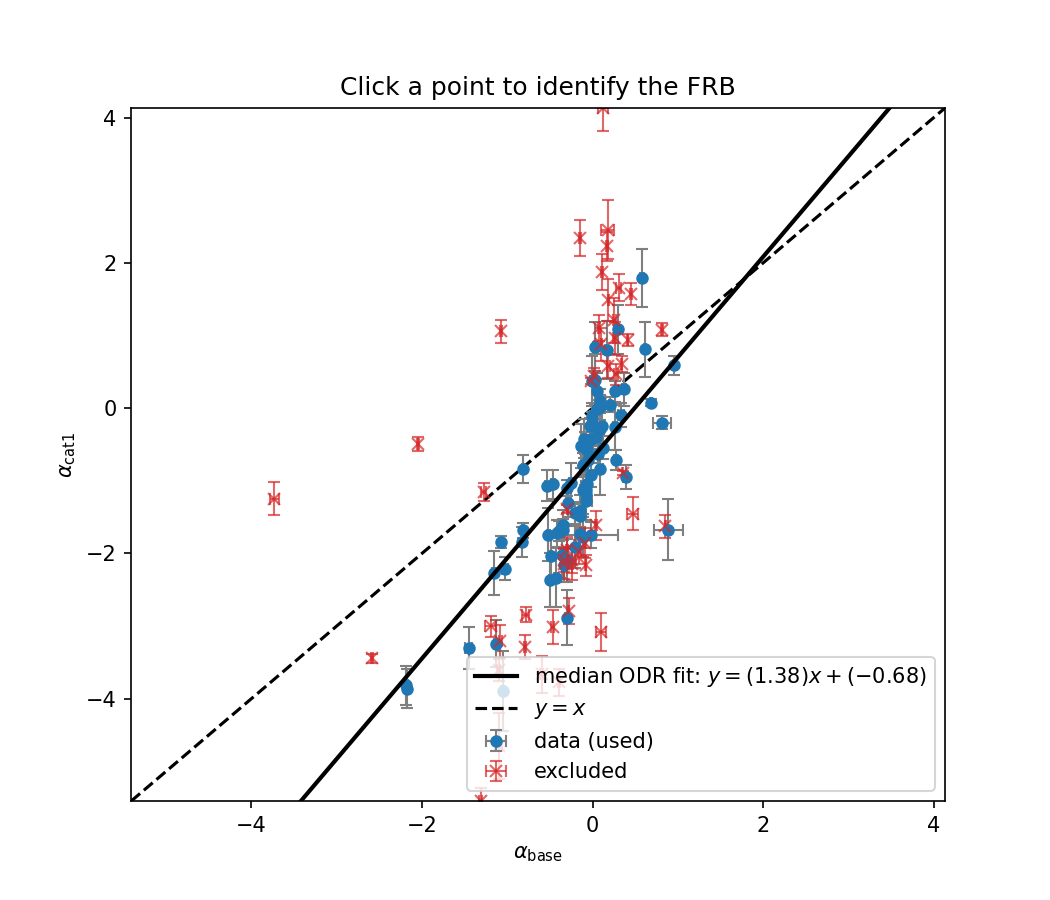

In [14]:
# --- Interactive final plot: click a point to print its FRB name ---
# Requires an interactive backend (ipympl) so click events work in the notebook:
#   pip install ipympl mplcursors
%matplotlib widget
import mplcursors

# Carry the FRB name column through the same masks used for x/y (mask -> keep_10 -> keep_5)
frb_names_all = clean["frb_name"].values
frb_m  = frb_names_all[mask]
frb_10 = frb_m[keep_10]
frb_5  = frb_10[keep_5]

# Names for the excluded points, built the same way x_excl_5/y_excl_5 were built
frb_excl_5 = np.concatenate([
    frb_names_all[~mask],       # manually dropped
    frb_m[outliers_10sigma],    # 10-sigma clipped
    frb_10[outliers_5sigma],    # 5-sigma clipped
])

fig2, ax2 = plt.subplots(figsize=(7, 6), dpi=150)

ax2.plot(x_fit, y_median, color="black", linewidth=2,
         label=fr"median ODR fit: $y=({a_med:.2f})x+({b_med:.2f})$", zorder=3)
ax2.plot(lims, lims, "k--", linewidth=1.5, label=r"$y=x$", zorder=2)

used_err = ax2.errorbar(x_m, y_m, xerr=xerr_m, yerr=yerr_m,
                         fmt="o", markersize=5, capsize=3, elinewidth=1,
                         color="tab:blue", ecolor="tab:gray", label="data (used)", zorder=2)

excl_err = None
if len(x_excl_5):
    excl_err = ax2.errorbar(x_excl_5, y_excl_5, xerr=xerr_excl_5, yerr=yerr_excl_5,
                             fmt="x", markersize=6, capsize=3, elinewidth=1,
                             color="tab:red", ecolor="tab:red", alpha=0.7, label="excluded", zorder=2)

ax2.set_xlim(lims)
ax2.set_ylim(lims)
ax2.set_xlabel(r'$\alpha_{\mathrm{base}}$')
ax2.set_ylabel(r'$\alpha_{\mathrm{cat1}}$')
ax2.set_title("Click a point to identify the FRB")
ax2.legend(loc="lower right")

# Cursor for the "used" (blue) points
cursor_used = mplcursors.cursor(used_err, hover=False)

@cursor_used.connect("add")
def on_click_used(sel):
    i = sel.index
    sel.annotation.set_text(
        f"{frb_5[i]}\n"
        f"x={x_m[i]:.3f} ± {xerr_m[i]:.3f}\n"
        f"y={y_m[i]:.3f} ± {yerr_m[i]:.3f}"
    )

# Cursor for the "excluded" (red) points
if excl_err is not None:
    cursor_excl = mplcursors.cursor(excl_err, hover=False)

    @cursor_excl.connect("add")
    def on_click_excl(sel):
        i = sel.index
        sel.annotation.set_text(
            f"{frb_excl_5[i]} (excluded)\n"
            f"x={x_excl_5[i]:.3f} ± {xerr_excl_5[i]:.3f}\n"
            f"y={y_excl_5[i]:.3f} ± {yerr_excl_5[i]:.3f}"
        )

plt.show()

In [15]:
# --- Count points below y = x, using only the surviving (non-removed) data ---
n_below_final = (y_5 < x_5).sum()
n_total_final = len(x_5)
frac_below_final = n_below_final / n_total_final

print(f"below y=x (final, cleaned sample): {n_below_final} / {n_total_final} "
      f"({frac_below_final:.1%})")
print(f"(compare to original full sample: {n_below} / {n_total} ({frac_below:.1%}))")

below y=x (final, cleaned sample): 72 / 81 (88.9%)
(compare to original full sample: 98 / 130 (75.4%))
